In [ ]:
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Data Quality checks, cleaning

In [2]:
#reading in input
df = pd.read_csv(r'BI Fullstack case study dataset.csv', sep=',', quoting=csv.QUOTE_NONE)

df.iloc[:, [0, -1]] = df.iloc[:, [0, -1]].apply(lambda x: x.astype(str).str.replace('"', ''))
df.columns = df.columns.str.replace('"', '')

In [3]:
#checking for missings
missing = df[df.isna().any(axis=1)]
missing

,engine_id,timestamp,oph,pist_m,issue_type,bmep,ng_imp,past_dmg,resting_analysis_results,rpm_max,full_load_issues,number_up,number_tc,op_set_1,op_set_2,op_set_3,breakdown
440,ENG045,2021-02-21,11990,2,2,18.9,365,1,2,1605,"""",NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.iloc[439:445]

,engine_id,timestamp,oph,pist_m,issue_type,bmep,ng_imp,past_dmg,resting_analysis_results,rpm_max,full_load_issues,number_up,number_tc,op_set_1,op_set_2,op_set_3,breakdown
439,ENG044,2024-11-15,3160,1,3,12.4,135,0,0,1395,0,0.0,1.0,0.70,0.72,0.77,0
440,ENG045,2021-02-21,11990,2,2,18.9,365,1,2,1605,"""",NaN,NaN,NaN,NaN,NaN,NaN
441,ENG045,2021-02-21,11990,2,2,18.9,365,1,2,1605,1,5.0,2.0,0.91,0.86,0.96,1
442,ENG045,2021-07-13,5470,1,1,14.2,170,0,1,1470,0,2.0,1.0,0.77,0.80,0.84,0
443,ENG045,2022-02-01,7910,3,4,16.5,260,1,1,1500,1,3.0,2.0,0.82,0.76,0.89,1
444,ENG045,2022-06-05,3380,2,1,13.4,140,0,0,1425,0,0.0,1.0,0.71,0.75,0.80,0


In [5]:
#only row 440 has data quality issue, drop missing
df=df.dropna()
df['breakdown']=df['breakdown'].astype(int)
df['full_load_issues']=df['full_load_issues'].astype(int)


In [6]:
#checking for extreme values, row counts
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.describe()
#looking good

,oph,pist_m,issue_type,bmep,ng_imp,past_dmg,resting_analysis_results,rpm_max,full_load_issues,number_up,number_tc,op_set_1,op_set_2,op_set_3,breakdown
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7531.340000,1.950000,2.300000,15.61300,237.550000,0.500000,0.998000,1500.960000,0.500000,2.596000,1.500000,0.804040,0.795140,0.873240,0.500000
std,3302.812794,0.807964,1.101102,2.42135,91.692762,0.500501,0.776661,74.358839,0.500501,1.908945,0.500501,0.075789,0.046035,0.065241,0.500501
min,2680.000000,1.000000,1.000000,11.80000,120.000000,0.000000,0.000000,1385.000000,0.000000,0.000000,1.000000,0.680000,0.710000,0.760000,0.000000
25%,4840.000000,1.000000,1.000000,13.40000,155.000000,0.000000,0.000000,1440.000000,0.000000,1.000000,1.000000,0.740000,0.760000,0.820000,0.000000
50%,7430.000000,2.000000,2.000000,15.55000,232.500000,0.500000,1.000000,1490.000000,0.500000,2.500000,1.500000,0.815000,0.790000,0.880000,0.500000
75%,10095.000000,3.000000,3.000000,17.70000,315.000000,1.000000,2.000000,1580.000000,1.000000,4.000000,2.000000,0.880000,0.830000,0.940000,1.000000
max,13450.000000,3.000000,4.000000,19.30000,395.000000,1.000000,2.000000,1625.000000,1.000000,6.000000,2.000000,0.930000,0.880000,0.970000,1.000000


In [13]:
df.dtypes

engine_id                              str
timestamp                   datetime64[us]
oph                                  int64
pist_m                               int64
issue_type                           int64
bmep                               float64
ng_imp                               int64
past_dmg                             int64
resting_analysis_results             int64
rpm_max                              int64
full_load_issues                     int64
number_up                          float64
number_tc                          float64
op_set_1                           float64
op_set_2                           float64
op_set_3                           float64
breakdown                            int64
dtype: object

In [ ]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [14]:
df.to_excel(r'src.xlsx',index=False)

In [ ]:

import pandas as pd
import csv
import sqlite3

from pathlib import Path
import sys

sys.path.insert(0, str(Path(__file__).parent / "01_input"))
sys.path.insert(0, str(Path(__file__).parent / "02_data_model"))
sys.path.insert(0, str(Path(__file__).parent / "03_db"))
import data_cleaning
import modeling
import db_building

def main():
    print("=" * 60)
    print("INNIO PROJECT - DATA PIPELINE")
    print("=" * 60)
    
    # Step 1: Load input data
    print("\n[Step 1] Loading input data...")
    input_file = Path("01_input/BI Fullstack case study dataset.csv")
    df = data_cleaning.data_cleaning(input_file)

    # Step 2: Transform with backend_model
    print("\n[Step 2] Transforming data (backend_model)...")
    tables_dict = modeling.modeling(df)
    print(f"✓ Generated {len(tables_dict)} tables:")
    for name in tables_dict.keys():
        print(f"  - {name}")
    
    # Step 3: Build database
    print("\n[Step 3] Building database...")
    db_building.db_building(tables_dict)
    
    print("\n" + "=" * 60)
    print("✓ Pipeline completed successfully!")
    print("=" * 60)

if __name__ == "__main__":
    main()


# 2. EDA

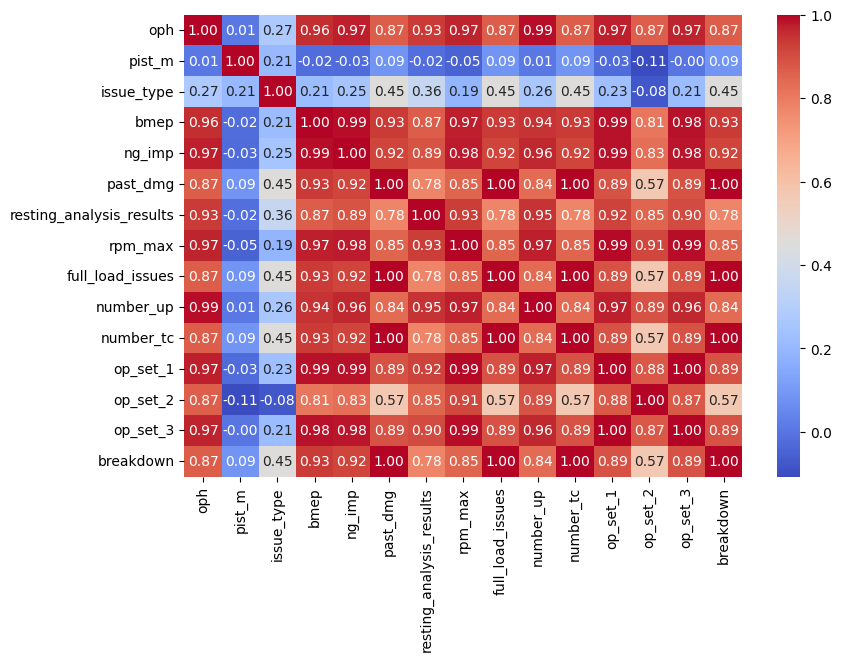

In [8]:
r = df.corr(numeric_only=True)
plt.figure(figsize=(9,6))
sns.heatmap(r, annot=True, cmap='coolwarm',fmt='.2f')
plt.show()

#multicollinearity -> inr eal business scenarios, it (usually) means that these variables are measuring the same latent variable 

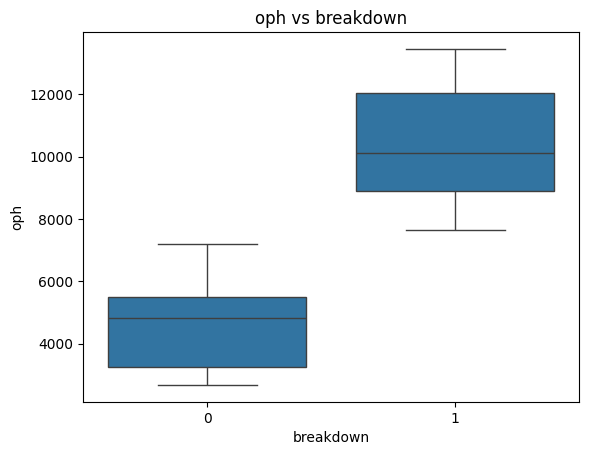

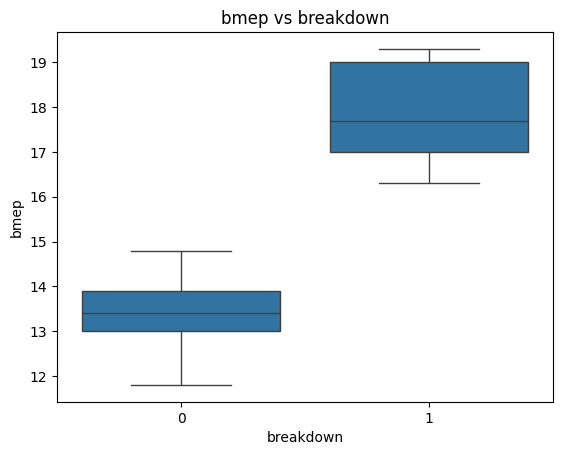

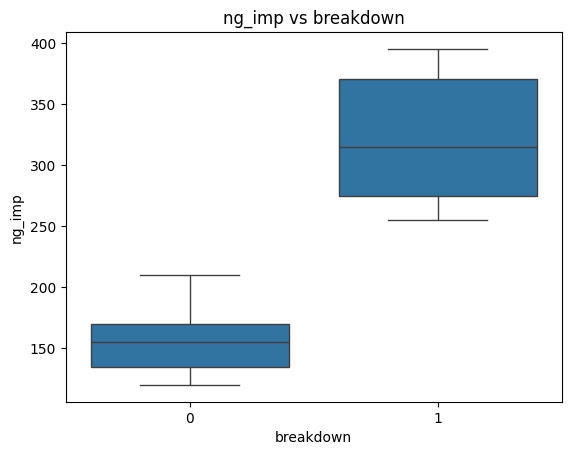

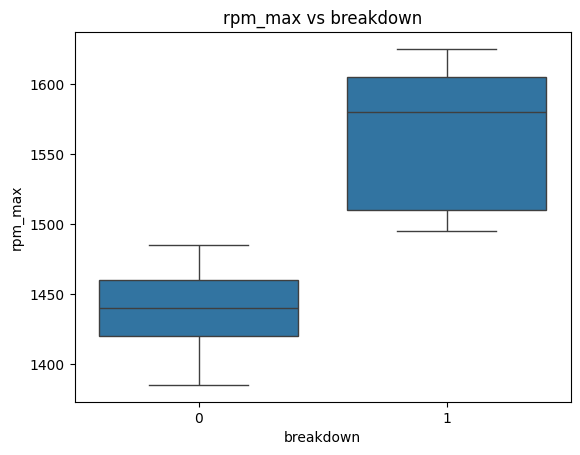

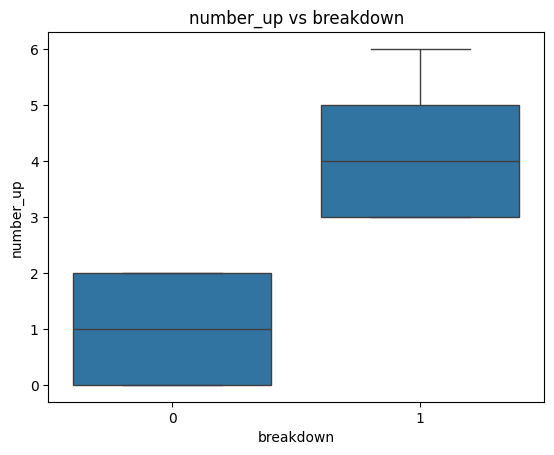

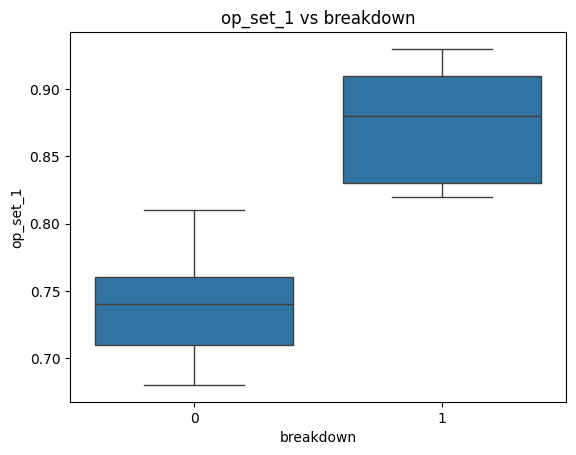

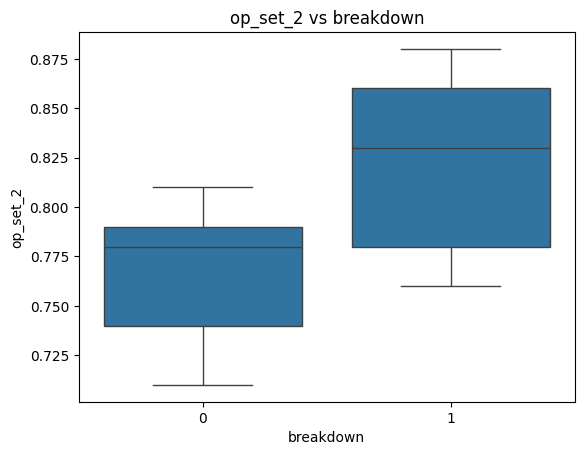

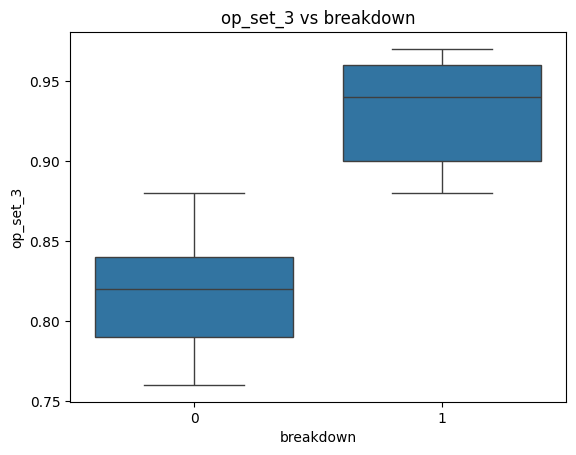

In [15]:
metrics_cols = ['oph', 'bmep', 'ng_imp', 'rpm_max', 'number_up', 'op_set_1', 'op_set_2', 'op_set_3']
for col in metrics_cols:
    sns.boxplot(x='breakdown', y=col, data=df)
    plt.title(f'{col} vs breakdown')
    plt.show()

In [10]:
cat_cols = ["pist_m","issue_type","resting_analysis_results","past_dmg","full_load_issues","number_tc"]
summary_list = []
for col in cat_cols:
    agg = df.groupby(col).agg(breakdown_rate=("breakdown", "mean"),count=("breakdown", "count")).reset_index()
    agg["variable"] = col
    agg = agg.rename(columns={col: "category_value"})
    summary_list.append(agg)
summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

,category_value,breakdown_rate,count,variable
0,1.0,0.482955,176,pist_m
1,2.0,0.433526,173,pist_m
2,3.0,0.596026,151,pist_m
3,1.0,0.000000,150,issue_type
4,2.0,1.000000,150,issue_type
5,3.0,0.000000,100,issue_type
6,4.0,1.000000,100,issue_type
7,0.0,0.000000,151,resting_analysis_results
8,1.0,0.502513,199,resting_analysis_results
9,2.0,1.000000,150,resting_analysis_results
